# INTRODUCTION <a class="anchor"  id="introduction"></a>

A brain tumor is an abnormal mass of cells within or around the brain, categorized as primary (starting in the brain) or secondary (spreading from elsewhere). They can be benign (noncancerous) or malignant (cancerous), with over 100 different types impacting the central nervous system. Common symptoms include new headaches, seizures, and personality changes. > https://my.clevelandclinic.org/health/diseases/6149-brain-cancer-brain-tumor 

Diagnosis  
a. Neurological Exams: Testing vision, hearing, balance, strength, and reflexes.  
b. Imaging Tests: MRI (magnetic resonance imaging) is common, often enhanced with contrast dye, and CT scans. (This study)  
c. Biopsy: Taking a tissue sample to determine the type and grade of the tumor.

Types of Brain Tumors  
a. Benign (Noncancerous): Generally slow-growing, such as meningiomas or pituitary adenomas.  
b. Malignant (Cancerous): Often fast-growing, such as glioblastomas, which are the most common primary tumor in adults.

## A. Usage

In this notebook, we'll maximize the use of kaggle notebook along with help of powerful GPU offered.  
This project is beneficial for inital diagnosis for brain tumor detection - binary classification (Tumor / No Tumor)

# Table of Contents

- [INTRODUCTION](#introduction)
- [IMPORTING NECESSARY LIBRARIES](#importing-necessary-libraries)
- [IMPORTING FILES](#importing-files)
- [VISUALIZING DATASET DISTRIBUTIONS](#visualizing-dataset-distributions)
- [GENERATING SAMPLE IMAGES (ORIGINAL)](#generating-sample-images-original)
- [PYTORCH DEEP LEARNING](#pytorch-deep-learning)
- [IMPORTING PYTORCH LIBRARIES](#importing-pytorch-libraries)
- [TORCH RANDOM UPSAMPLING](#torch-random-upsampling)
- [TRAIN & VALIDATION DATA LOADER](#train--validation-data-loader)
- [SIMPLE CNN MODEL](#simple-cnn-model)
- [RESNET50 CNN MODEL](#resnet50-cnn-model)
- [EFFICIENTNETB4 CNN MODEL](#efficientnetb4-cnn-model)
- [EALY STOPPING CLASS](#ealy-stopping-class)
- [TORCHTRAINER](#torchtrainer)
- [MODEL DESCRIPTION AND ITS TOTAL PARAMETERS](#model-description-and-its-total-parameters)
- [SIMPLE CNN MODEL TRAINING AND VISUALIZATION](#simple-cnn-model-training-and-visualization)
- [RESNET CNN MODEL TRAINING AND VISUALIZATION](#resnet-cnn-model-training-and-visualization)
- [EFFICIENTNET CNN MODEL TRAINING AND VISUALIZATION](#efficientnet-cnn-model-training-and-visualization)
- [CONCLUSION](#conclusion)
  
---

## IMPORTING NECESSARY LIBRARIES <a class="anchor"  id="importing-necessary-libraries"></a>

In [61]:
# Importing Initial Libraries
import os
import tqdm
import random
import time

# Importing Data Visual Libraries
import matplotlib.pyplot as plt
import numpy as np
import cv2

# Importing SKLearn Preprocessing and TrainTestSplit
from sklearn.preprocessing import LabelBinarizer
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix
%matplotlib inline 

# IMPORTING FILES <a class="anchor"  id="importing-files"></a>

In [2]:
path = "../input/datasets/navoneel/brain-mri-images-for-brain-tumor-detection"
yes_path = "../input/datasets/navoneel/brain-mri-images-for-brain-tumor-detection/yes"
no_path = "../input/datasets/navoneel/brain-mri-images-for-brain-tumor-detection/no"

# VISUALIZING DATASET DISTRIBUTIONS

../input/datasets/navoneel/brain-mri-images-for-brain-tumor-detection/yes
Total Images for YES is: 155
../input/datasets/navoneel/brain-mri-images-for-brain-tumor-detection/no
Total Images for NO is: 98


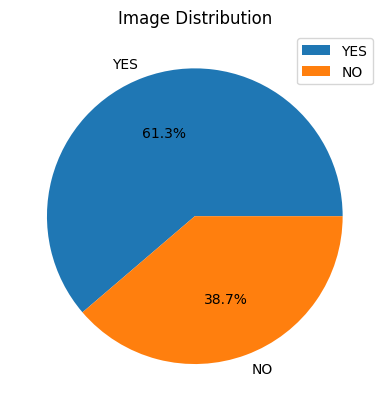

In [3]:
yes_counts = 0
no_counts = 0

# Count images in YES path
for dirpath, dirnames, filenames in os.walk(yes_path):
    print(dirpath)
    print(f"Total Images for YES is: {len(filenames)}")
    yes_counts += len(filenames)

# Count images in NO path
for dirpath, dirnames, filenames in os.walk(no_path):
    print(dirpath)
    print(f"Total Images for NO is: {len(filenames)}")
    no_counts += len(filenames)

# Plot pie chart
plt.pie([yes_counts, no_counts], labels=["YES", "NO"], autopct="%1.1f%%")
plt.title("Image Distribution")
plt.legend()
plt.show()

### 1.1 SETTING CONSTANTS AND PARAMETERS 

In [9]:
random_seed = 28
epoch = 30
batch_size = 32
sample_size = 10

# GENERATING SAMPLE IMAGES (ORIGINAL)

> Here, we will generate sample images from the data

In [4]:
def load_samples(base_path, num_samples):
    yes_data = []
    no_data = []

    for cls in ["yes", "no"]:
        folder = os.path.join(base_path, cls)
        images = [img for img in os.listdir(folder) if img.lower().endswith((".png", ".jpg", ".jpeg"))]

        sampled = random.sample(images, min(num_samples, len(images)))

        for img_name in sampled:
            img_path = os.path.join(folder, img_name)
            img = cv2.imread(img_path)

            if img is None:
                continue

            img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

            if cls == "yes":
                yes_data.append(img)
            else:
                no_data.append(img)

    return yes_data, no_data

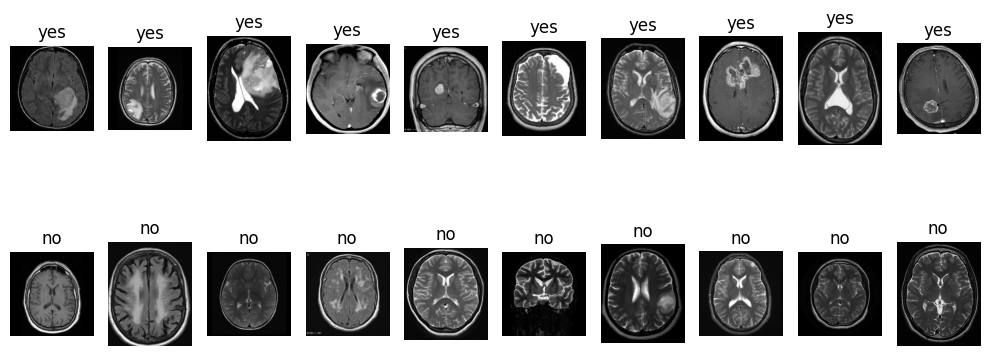

In [5]:
def show_samples(samples):

    plt.figure(figsize=(10, 5))

    for i, (img, label) in enumerate(samples):
        plt.subplot(2, len(samples)//2, i+1)
        plt.imshow(img)
        plt.title(label)
        plt.axis('off')

    plt.tight_layout()
    plt.show()

yes_data, no_data = load_samples(path, 10)
samples = [(img, "yes") for img in yes_data] + \
          [(img, "no") for img in no_data]

show_samples(samples)

#  **PYTORCH DEEP LEARNING**

> Pytorch is very powerful in terms of personalization and making a DL pipeline from the scratch.

## IMPORTING PYTORCH LIBRARIES

In [33]:
# Pytorch
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, Subset
from torch.utils.data import WeightedRandomSampler
from collections import Counter
import torch.nn.functional as F

# Torchvision
from torchvision import datasets, transforms, models
from torchvision.models import resnet50, ResNet50_Weights, efficientnet_b4, EfficientNet_B4_Weights

# Defaultdict
from collections import defaultdict

## IMPORTING SKLEARN LIBRARIES

In [39]:
from sklearn.metrics import (
    confusion_matrix,
    precision_score,
    recall_score,
    f1_score,
    accuracy_score,
    classification_report,
    roc_auc_score,
    roc_curve,
    auc
)

In [12]:
# Root path that contains ONLY "yes" and "no" folders
path = "../input/datasets/navoneel/brain-mri-images-for-brain-tumor-detection/brain_tumor_dataset"

transform = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.ToTensor()
])

# Load dataset once, pointing to the root folder
dataset = datasets.ImageFolder(root=path, transform=transform)

# Check mapping
print(dataset.class_to_idx)

# Create DataLoader
loader = DataLoader(dataset, batch_size=batch_size, shuffle=True)

# Example: get one batch
images, labels = next(iter(loader))
print(images.shape)   
print(labels)

{'no': 0, 'yes': 1}
torch.Size([32, 3, 128, 128])
tensor([1, 0, 1, 1, 1, 1, 1, 1, 1, 0, 0, 1, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
        0, 1, 0, 1, 0, 0, 0, 1])


# TORCH RANDOM UPSAMPLING

> Original images has total of 155 vs 98. 63.22% imbalanced (With Tumor vs No Tumor)

In [13]:
# Targets
targets = torch.tensor(dataset.targets)

print("Before WRS:", Counter(targets.tolist()))

# Class balancing
class_counts = torch.bincount(targets)
class_weights = 1. / class_counts.float()
sample_weights = class_weights[targets]

sampler = WeightedRandomSampler(
    weights=sample_weights,
    num_samples=len(dataset),
    replacement=True
)

loader = DataLoader(dataset, batch_size=32, sampler=sampler)

sampled_counter = Counter()

for _, batch_labels in loader:
    sampled_counter.update(batch_labels.tolist())

print("After WRS:", sampled_counter)

# One batch check
images, batch_labels = next(iter(loader))
print("One batch distribution:", Counter(batch_labels.tolist()))
print("Batch shape:", images.shape)

Before WRS: Counter({1: 155, 0: 98})
After WRS: Counter({1: 130, 0: 123})
One batch distribution: Counter({0: 19, 1: 13})
Batch shape: torch.Size([32, 3, 128, 128])


## TRAIN TEST SPLIT

In [14]:
targets = dataset.targets

train_idx, val_idx = train_test_split(
    list(range(len(dataset))),
    test_size=0.2,
    stratify=targets,
    random_state=random_seed
)

train_targets = [targets[i] for i in train_idx]
train_targets = torch.tensor(train_targets)

class_counts = torch.bincount(train_targets)
class_weights = 1. / class_counts.float()
sample_weights = class_weights[train_targets]

# Sampler
sampler = WeightedRandomSampler(
    weights=sample_weights,
    num_samples=len(train_targets),
    replacement=True
)

# Applying Transformations
train_transform = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(20),
    transforms.ColorJitter(0.2, 0.2),
    transforms.ToTensor()
])

val_transform = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.ToTensor()
])

In [15]:
train_dataset = Subset(
    datasets.ImageFolder(root=path, transform=train_transform),
    train_idx
)

val_dataset = Subset(
    datasets.ImageFolder(root=path, transform=val_transform),
    val_idx
)

# TRAIN & VALIDATION DATA LOADER

In [16]:
train_loader = DataLoader(
    train_dataset,
    batch_size=32,
    sampler=sampler
)

val_loader = DataLoader(
    val_dataset,
    batch_size=32,
    shuffle=False
)

# SIMPLE CNN MODEL

In [17]:
class SimpleCNN(nn.Module):
    def __init__(self):
        super().__init__()

        # --- Feature extractor ---
        self.conv_block1 = nn.Sequential(
            nn.Conv2d(3, 16, kernel_size=3, padding=1),
            nn.BatchNorm2d(16),
            nn.ReLU(),
            nn.MaxPool2d(2)  # 128 → 64
        )

        self.conv_block2 = nn.Sequential(
            nn.Conv2d(16, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2)  # 64 → 32
        )

        self.conv_block3 = nn.Sequential(
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2)  # 32 → 16
        )

        self.conv_block4 = nn.Sequential(
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(2)  # 16 → 8
        )

        # --- Classifier ---
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * 8 * 8, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(128, 1)  # binary output
        )

    def forward(self, x):
        x = self.conv_block1(x)
        x = self.conv_block2(x)
        x = self.conv_block3(x)
        x = self.conv_block4(x)
        x = self.classifier(x)
        return x

# RESNET50 CNN MODEL

In [18]:
class BrainTumorResNet50(nn.Module):
    def __init__(self):
        super().__init__()

        # Load pretrained ResNet50
        self.backbone = models.resnet50(
            weights=ResNet50_Weights.IMAGENET1K_V1
        )

        # Freeze all layers first
        for param in self.backbone.parameters():
            param.requires_grad = False

        # Unfreeze last block (layer4)
        for param in self.backbone.layer4.parameters():
            param.requires_grad = True

        # Replace classifier (fc layer)
        in_features = self.backbone.fc.in_features

        self.backbone.fc = nn.Sequential(
            nn.Linear(in_features, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(256, 1)  # binary classification
        )

    def forward(self, x):
        return self.backbone(x)

# EFFICIENTNETB4 CNN MODEL

In [19]:
class BrainTumorEffNetB4(nn.Module):
    def __init__(self):
        super().__init__()

        # Load pretrained EfficientNet-B4
        self.backbone = models.efficientnet_b4(
            weights=EfficientNet_B4_Weights.IMAGENET1K_V1
        )

        # Freeze all layers
        for param in self.backbone.parameters():
            param.requires_grad = False

        # Unfreeze last few layers (classifier block equivalent)
        for param in self.backbone.features[-1].parameters():
            param.requires_grad = True

        # Replace classifier
        in_features = self.backbone.classifier[1].in_features

        self.backbone.classifier = nn.Sequential(
            nn.Dropout(p=0.5),
            nn.Linear(in_features, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(256, 1)  # binary output
        )

    def forward(self, x):
        return self.backbone(x)

# EALY STOPPING CLASS

In [20]:
class EarlyStopping:
    def __init__(self, patience=7, min_delta=0.0):
        self.patience = patience
        self.min_delta = min_delta
        self.best_loss = float("inf")
        self.counter = 0
        self.best_model = None

    def __call__(self, val_loss, model):
        if val_loss < self.best_loss - self.min_delta:
            self.best_loss = val_loss
            self.counter = 0
            self.best_model = model.state_dict()
        else:
            self.counter += 1

        if self.counter >= self.patience:
            print("Early stopping triggered")
            if self.best_model is not None:
                model.load_state_dict(self.best_model)
            return True

        return False

# TORCHTRAINER

In [41]:
class TorchTrainer:
    def __init__(
        self,
        model,
        train_loader,
        val_loader,
        optimizer,
        criterion,
        device,
        patience=7
    ):
        self.model = model.to(device)
        self.train_loader = train_loader
        self.val_loader = val_loader
        self.optimizer = optimizer
        self.criterion = criterion
        self.device = device

        self.early_stopper = EarlyStopping(patience=patience)
        self.history = defaultdict(list)

    def train_one_epoch(self):
        self.model.train()
        total_loss = 0
        correct = 0
        total = 0

        start_time = time.time() 

        for images, labels in self.train_loader:
            images = images.to(self.device)
            labels = labels.float().unsqueeze(1).to(self.device)

            self.optimizer.zero_grad()
            outputs = self.model(images)

            loss = self.criterion(outputs, labels)
            loss.backward()
            self.optimizer.step()

            total_loss += loss.item()

            # Accuracy
            preds = (torch.sigmoid(outputs) > 0.5).float()
            correct += (preds == labels).sum().item()
            total += labels.size(0)

            end_time = time.time()

            steps = len(self.train_loader)
            ms_per_step = (end_time - start_time) / steps * 1000

        acc = correct / total
        return total_loss / len(self.train_loader), acc, ms_per_step

    def validate(self):
        self.model.eval()
        total_loss = 0
        correct = 0
        total = 0

        with torch.no_grad():
            for images, labels in self.val_loader:
                images = images.to(self.device)
                labels = labels.float().unsqueeze(1).to(self.device)

                outputs = self.model(images)
                loss = self.criterion(outputs, labels)

                total_loss += loss.item()

                # Accuracy
                preds = (torch.sigmoid(outputs) > 0.5).float()
                correct += (preds == labels).sum().item()
                total += labels.size(0)

        acc = correct / total
        return total_loss / len(self.val_loader), acc

    def fit(self, epochs):
        for epoch in range(epochs):
            
            start_time = time.time()
            
            train_loss, train_acc, train_ms = self.train_one_epoch()
            val_loss, val_acc = self.validate()

            epoch_time = time.time() - start_time

            self.history["train_loss"].append(train_loss)
            self.history["train_acc"].append(train_acc)
            self.history["val_loss"].append(val_loss)
            self.history["val_acc"].append(val_acc)
            self.history["epoch_time"].append(epoch_time)

            print(
                f"Epoch {epoch+1}: "
                f"train_loss={train_loss:.4f}, train_acc={train_acc:.4f}, "
                f"val_loss={val_loss:.4f}, val_acc={val_acc:.4f}, "
                f"time={epoch_time:.2f}s"
            )

            if self.early_stopper(val_loss, self.model):
                break

        return self.history

## MODEL PERFORMANCE FUNCTION

In [42]:
def plot_training_metrics(history):
    # Required
    tr_loss = history.get('train_loss', [])
    val_loss = history.get('val_loss', [])

    # Optional metrics (if you add them later)
    tr_acc = history.get('train_acc', [])
    val_acc = history.get('val_acc', [])
    tr_per = history.get('train_precision', [])
    val_per = history.get('val_precision', [])
    tr_recall = history.get('train_recall', [])
    val_recall = history.get('val_recall', [])

    epochs = range(1, len(tr_loss) + 1)

    plt.figure(figsize=(16, 10))

    # ---- LOSS ----
    plt.subplot(2, 2, 1)
    plt.plot(epochs, tr_loss, label='Train Loss')
    plt.plot(epochs, val_loss, label='Val Loss')

    if val_loss:
        idx = np.argmin(val_loss)
        plt.scatter(idx+1, val_loss[idx], label=f'Best Epoch={idx+1}')

    plt.title('Loss')
    plt.xlabel('Epochs')
    plt.legend()
    plt.grid()

    # ---- ACCURACY ----
    if tr_acc and val_acc:
        plt.subplot(2, 2, 2)
        plt.plot(epochs, tr_acc, label='Train Acc')
        plt.plot(epochs, val_acc, label='Val Acc')

        idx = np.argmax(val_acc)
        plt.scatter(idx+1, val_acc[idx], label=f'Best Epoch={idx+1}')

        plt.title('Accuracy')
        plt.xlabel('Epochs')
        plt.legend()
        plt.grid()

    # ---- PRECISION ----
    if tr_per and val_per:
        plt.subplot(2, 2, 3)
        plt.plot(epochs, tr_per, label='Train Precision')
        plt.plot(epochs, val_per, label='Val Precision')

        idx = np.argmax(val_per)
        plt.scatter(idx+1, val_per[idx], label=f'Best Epoch={idx+1}')

        plt.title('Precision')
        plt.xlabel('Epochs')
        plt.legend()
        plt.grid()

    # ---- RECALL ----
    if tr_recall and val_recall:
        plt.subplot(2, 2, 4)
        plt.plot(epochs, tr_recall, label='Train Recall')
        plt.plot(epochs, val_recall, label='Val Recall')

        idx = np.argmax(val_recall)
        plt.scatter(idx+1, val_recall[idx], label=f'Best Epoch={idx+1}')

        plt.title('Recall')
        plt.xlabel('Epochs')
        plt.legend()
        plt.grid()

    plt.suptitle("Training Metrics", fontsize=14)
    plt.tight_layout()
    plt.show()

### GET PREDICTION FUNCTION

In [43]:
def get_predictions(model, dataloader, device):
    model.eval()

    all_labels = []
    all_probs = []

    with torch.no_grad():
        for images, labels in dataloader:
            images = images.to(device)

            outputs = model(images)
            probs = torch.sigmoid(outputs)

            all_probs.extend(probs.cpu().numpy().ravel())
            all_labels.extend(labels.numpy().ravel())

    return np.array(all_labels), np.array(all_probs)

## MODEL EVALUATION FUNCTION

In [24]:
def evaluate_model(model, dataloader, device, criterion):
    model.eval()
    total_loss = 0
    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in dataloader:
            images = images.to(device)
            labels = labels.float().unsqueeze(1).to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            preds = (torch.sigmoid(outputs) > 0.5).float()

            total_loss += loss.item()
            correct += (preds == labels).sum().item()
            total += labels.size(0)

    avg_loss = total_loss / len(dataloader)
    accuracy = correct / total

    return avg_loss, accuracy

## ROC_AUC CURVE FUNCTION

In [25]:
def plot_roc_auc(
    model,
    dataloader,
    device,
    title="ROC Curve",
    return_data=False
):
    model.eval()

    all_labels = []
    all_probs = []

    with torch.no_grad():
        for images, labels in dataloader:
            images = images.to(device)

            outputs = model(images)
            probs = torch.sigmoid(outputs)

            all_probs.extend(probs.cpu().numpy().ravel())
            all_labels.extend(labels.numpy().ravel())

    all_labels = np.array(all_labels)
    all_probs = np.array(all_probs)

    # Compute ROC
    fpr, tpr, thresholds = roc_curve(all_labels, all_probs)
    roc_auc = auc(fpr, tpr)

    # Plot
    plt.figure(figsize=(6, 5))
    plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.4f}")
    plt.plot([0, 1], [0, 1], linestyle='--')

    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title(title)
    plt.legend()
    plt.grid()
    plt.show()

    if return_data:
        return {
            "fpr": fpr,
            "tpr": tpr,
            "thresholds": thresholds,
            "auc": roc_auc
        }

## COMPUTE METRICS FUNCTION

In [26]:
def compute_metrics(labels, probs, threshold=0.5, class_names=("no", "yes")):
    preds = (probs > threshold).astype(int)

    cm = confusion_matrix(labels, preds)
    tn, fp, fn, tp = cm.ravel()

    metrics = {
        "accuracy": accuracy_score(labels, preds),
        "precision": precision_score(labels, preds, zero_division=0),
        "recall": recall_score(labels, preds, zero_division=0),
        "f1": f1_score(labels, preds, zero_division=0),
        "tn": tn,
        "fp": fp,
        "fn": fn,
        "tp": tp,
        "confusion_matrix": cm,
        "report": classification_report(labels, preds, target_names=class_names)
    }

    # ---- Plot Confusion Matrix ----
    plt.figure(figsize=(5, 4))
    plt.imshow(cm)
    plt.title("Confusion Matrix")
    plt.colorbar()

    ticks = np.arange(len(class_names))
    plt.xticks(ticks, class_names)
    plt.yticks(ticks, class_names)

    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            plt.text(j, i, cm[i, j], ha="center", va="center")

    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.tight_layout()
    plt.show()

    return metrics

# MODEL DESCRIPTION AND ITS TOTAL PARAMETERS

In [50]:
model0 = SimpleCNN()
model1 = BrainTumorResNet50()
model2 = BrainTumorEffNetB4()

def model_description(model, original_model=None):
    # Count total parameters
    total_params = sum(p.numel() for p in model.parameters())
    trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

    if original_model is not None:
        original_params = sum(p.numel() for p in original_model.parameters())
        percent = (total_params / original_params) * 100
        print(f"Total parameters: {total_params} ({percent:.2f}% of baseline)")
    else:
        print(f"Total parameters: {total_params}")

    print(f"Trainable parameters: {trainable_params}")

print("Simple CNN Parameters:")
model_description(model0)
print("\n")
print("Resnet50 CNN Parameters:")
model_description(model1, model1)
print("\n")
print("EfficientNetB4 CNN Parameters:")
model_description(model2, model2)

Simple CNN Parameters:
Total parameters: 1147009
Trainable parameters: 1147009


Resnet50 CNN Parameters:
Total parameters: 24033345 (100.00% of baseline)
Trainable parameters: 15490049


EfficientNetB4 CNN Parameters:
Total parameters: 18008393 (100.00% of baseline)
Trainable parameters: 1266177


#### CUDA DECLARATION

In [28]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# SIMPLE CNN MODEL TRAINING AND VISUALIZATION (MODEL 0)

In [44]:
def train_model_0(
    model,
    train_loader,
    val_loader,
    device,
    epochs=30,
    lr=1e-3,
    patience=7,
    criterion=None
):
    # Move model to device
    model = model.to(device)

    # Define loss if not provided
    if criterion is None:
        criterion = torch.nn.BCEWithLogitsLoss()

    # IMPORTANT: optimizer must use THIS model
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)

    # Trainer
    trainer = TorchTrainer(
        model=model,
        train_loader=train_loader,
        val_loader=val_loader,
        optimizer=optimizer,
        criterion=criterion,
        device=device,
        patience=patience
    )

    # Train
    history = trainer.fit(epochs=epochs)

    return trainer.model, history

Epoch 1: train_loss=0.0541, train_acc=0.9851, val_loss=0.4868, val_acc=0.9216, time=1.51s
Epoch 2: train_loss=0.0520, train_acc=0.9901, val_loss=0.4034, val_acc=0.9020, time=1.36s
Epoch 3: train_loss=0.0437, train_acc=0.9901, val_loss=0.5688, val_acc=0.8235, time=1.39s
Epoch 4: train_loss=0.0424, train_acc=0.9851, val_loss=0.2988, val_acc=0.9020, time=1.20s
Epoch 5: train_loss=0.0229, train_acc=0.9950, val_loss=0.4697, val_acc=0.8627, time=1.23s
Epoch 6: train_loss=0.0765, train_acc=0.9851, val_loss=0.3712, val_acc=0.8431, time=1.31s
Epoch 7: train_loss=0.0815, train_acc=0.9703, val_loss=0.2251, val_acc=0.9216, time=1.31s
Epoch 8: train_loss=0.0371, train_acc=0.9950, val_loss=0.2060, val_acc=0.9216, time=1.19s
Epoch 9: train_loss=0.0483, train_acc=0.9802, val_loss=0.3961, val_acc=0.8431, time=1.34s
Epoch 10: train_loss=0.0157, train_acc=1.0000, val_loss=0.5306, val_acc=0.8235, time=1.30s
Epoch 11: train_loss=0.1012, train_acc=0.9505, val_loss=0.4115, val_acc=0.9020, time=1.36s
Epoch 12

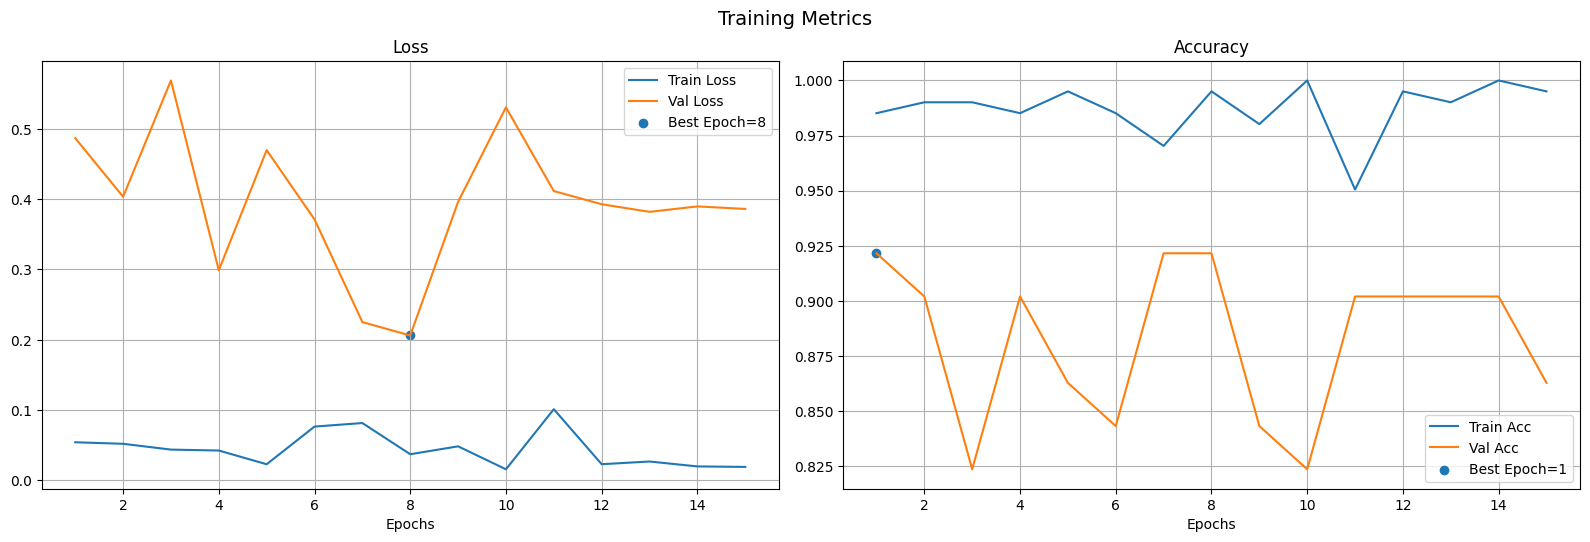

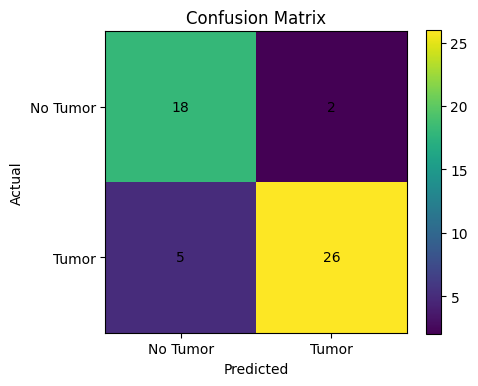

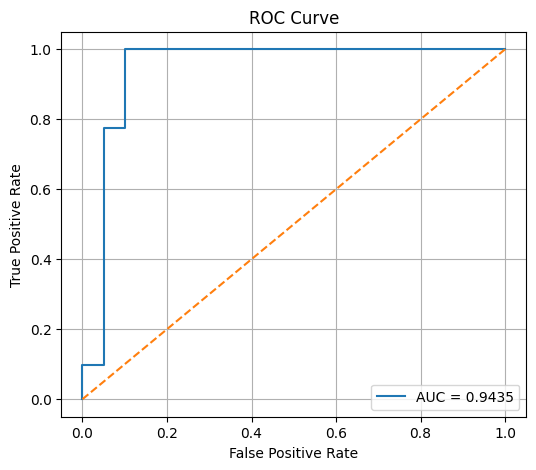

In [45]:
trained_model0, history0 = train_model_0(
    model=model0,
    train_loader=train_loader,
    val_loader=val_loader,
    device=device,
    epochs=epoch
)

plot_training_metrics(history0)

labels, probs = get_predictions(model0, val_loader, device)

metrics = compute_metrics(
    labels,
    probs,
    threshold=0.5,
    class_names=("No Tumor", "Tumor")
)

plot_roc_auc(model0, val_loader, device)

# RESNET MODEL TRAINING AND VISUALIZATION (MODEL 1)

In [57]:
def train_model_1(
    model,
    train_loader,
    val_loader,
    device,
    epochs=30,
    patience=7,
    criterion=None
):

    # Move model to device
    model = model.to(device)

    # Loss
    if criterion is None:
        criterion = torch.nn.BCEWithLogitsLoss()

    for param in model.backbone.parameters():
        param.requires_grad = False

    for param in model.backbone.layer4.parameters():
        param.requires_grad = True

    for param in model.backbone.fc.parameters():
        param.requires_grad = True

    optimizer = torch.optim.Adam([
        {"params": model.backbone.layer4.parameters(), "lr": 1e-5},
        {"params": model.backbone.fc.parameters(), "lr": 1e-4},
    ])

    trainer = TorchTrainer(
        model=model,
        train_loader=train_loader,
        val_loader=val_loader,
        optimizer=optimizer,
        criterion=criterion,
        device=device,
        patience=patience
    )

    history = trainer.fit(epochs=epochs)

    return trainer.model, history

Epoch 1: train_loss=0.1363, train_acc=0.9802, val_loss=0.3557, val_acc=0.8824, time=1.79s
Epoch 2: train_loss=0.0609, train_acc=0.9901, val_loss=0.3566, val_acc=0.8824, time=1.68s
Epoch 3: train_loss=0.0759, train_acc=0.9901, val_loss=0.3607, val_acc=0.8627, time=1.52s
Epoch 4: train_loss=0.1004, train_acc=0.9950, val_loss=0.3296, val_acc=0.8627, time=1.63s
Epoch 5: train_loss=0.0945, train_acc=0.9703, val_loss=0.4199, val_acc=0.9020, time=1.66s
Epoch 6: train_loss=0.0564, train_acc=1.0000, val_loss=0.4494, val_acc=0.8627, time=1.58s
Epoch 7: train_loss=0.0451, train_acc=0.9950, val_loss=0.4072, val_acc=0.8824, time=1.54s
Epoch 8: train_loss=0.0946, train_acc=0.9901, val_loss=0.4178, val_acc=0.8627, time=1.61s
Epoch 9: train_loss=0.0867, train_acc=0.9851, val_loss=0.4064, val_acc=0.8824, time=1.66s
Epoch 10: train_loss=0.0466, train_acc=0.9950, val_loss=0.3958, val_acc=0.8627, time=1.76s
Epoch 11: train_loss=0.0503, train_acc=0.9901, val_loss=0.3551, val_acc=0.8627, time=1.68s
Early st

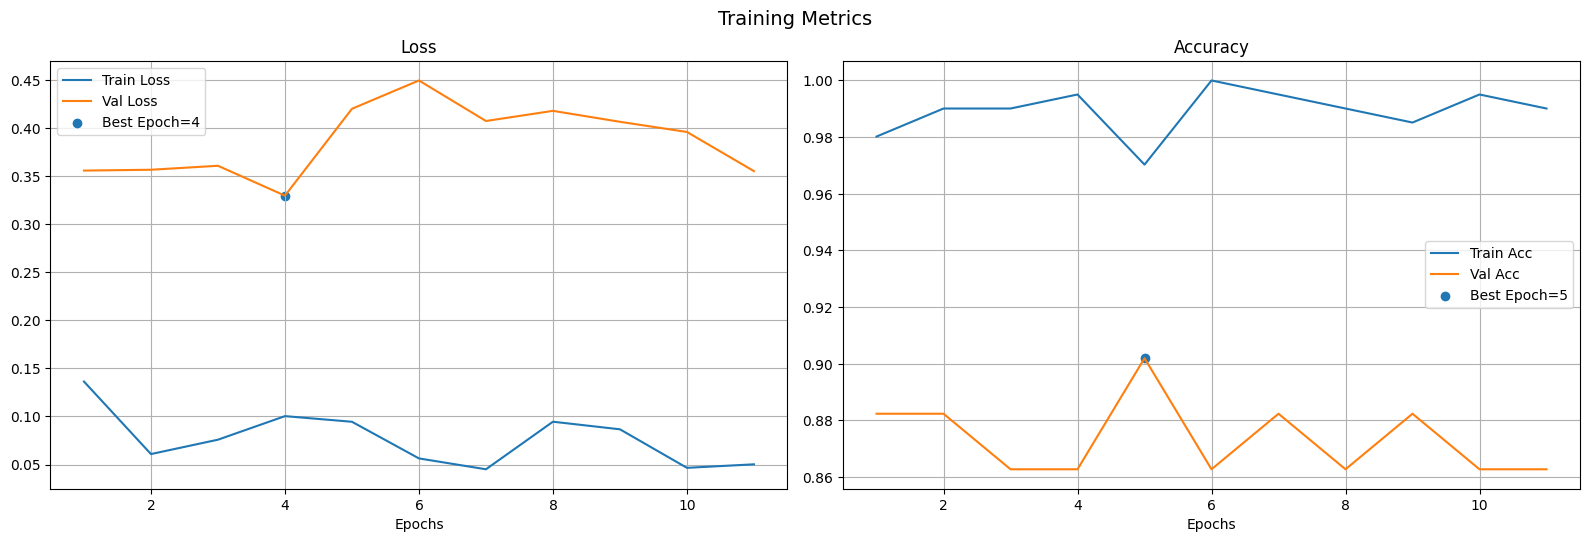

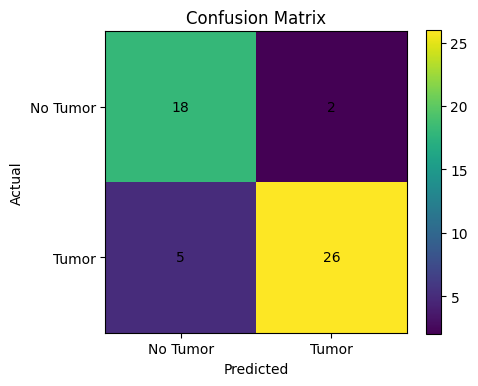

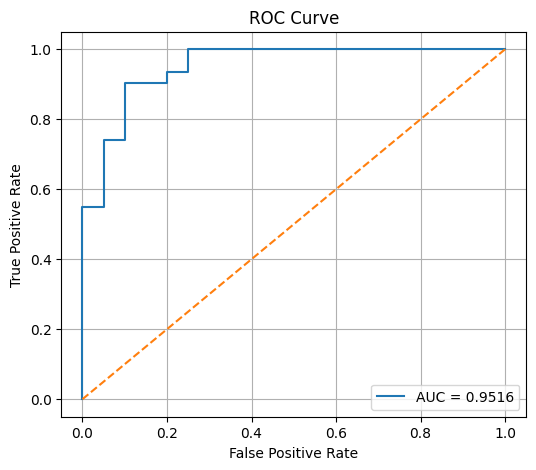

In [58]:
trained_model1, history1 = train_model_1(
    model=model1,
    train_loader=train_loader,
    val_loader=val_loader,
    device=device,
    epochs=epoch
)

plot_training_metrics(history1)

labels, probs = get_predictions(model1, val_loader, device)

metrics = compute_metrics(
    labels,
    probs,
    threshold=0.5,
    class_names=("No Tumor", "Tumor")
)

plot_roc_auc(model1, val_loader, device)

# EFFICIENTNET MODEL TRAINING AND VISUALIZATION (MODEL 2)

In [59]:
def train_model_2(
    model,
    train_loader,
    val_loader,
    device,
    epochs=30,
    patience=7,
    criterion=None
):

    # Move model to device
    model = model.to(device)

    # Loss
    if criterion is None:
        criterion = torch.nn.BCEWithLogitsLoss()

    backbone_features = model.backbone.features
    classifier = model.backbone.classifier

    for param in model.backbone.parameters():
        param.requires_grad = False

    for param in backbone_features[-1].parameters():
        param.requires_grad = True

    for param in classifier.parameters():
        param.requires_grad = True

    optimizer = torch.optim.Adam([
        {"params": backbone_features[-1].parameters(), "lr": 1e-5},
        {"params": classifier.parameters(), "lr": 1e-4},
    ])
    
    trainer = TorchTrainer(
        model=model,
        train_loader=train_loader,
        val_loader=val_loader,
        optimizer=optimizer,
        criterion=criterion,
        device=device,
        patience=patience
    )

    history = trainer.fit(epochs=epochs)

    return trainer.model, history

Epoch 1: train_loss=0.4377, train_acc=0.8267, val_loss=0.4969, val_acc=0.7255, time=1.80s
Epoch 2: train_loss=0.4910, train_acc=0.8168, val_loss=0.4738, val_acc=0.7451, time=1.62s
Epoch 3: train_loss=0.4730, train_acc=0.7673, val_loss=0.4894, val_acc=0.7647, time=1.60s
Epoch 4: train_loss=0.4651, train_acc=0.7921, val_loss=0.4665, val_acc=0.7843, time=1.66s
Epoch 5: train_loss=0.4549, train_acc=0.8020, val_loss=0.4687, val_acc=0.8039, time=1.47s
Epoch 6: train_loss=0.3882, train_acc=0.8663, val_loss=0.4718, val_acc=0.8235, time=1.62s
Epoch 7: train_loss=0.4673, train_acc=0.8267, val_loss=0.4452, val_acc=0.8235, time=1.57s
Epoch 8: train_loss=0.4124, train_acc=0.8069, val_loss=0.4481, val_acc=0.7843, time=1.53s
Epoch 9: train_loss=0.4262, train_acc=0.8020, val_loss=0.4546, val_acc=0.8039, time=1.60s
Epoch 10: train_loss=0.5241, train_acc=0.7426, val_loss=0.5342, val_acc=0.7451, time=1.50s
Epoch 11: train_loss=0.4960, train_acc=0.7871, val_loss=0.4877, val_acc=0.7843, time=1.45s
Epoch 12

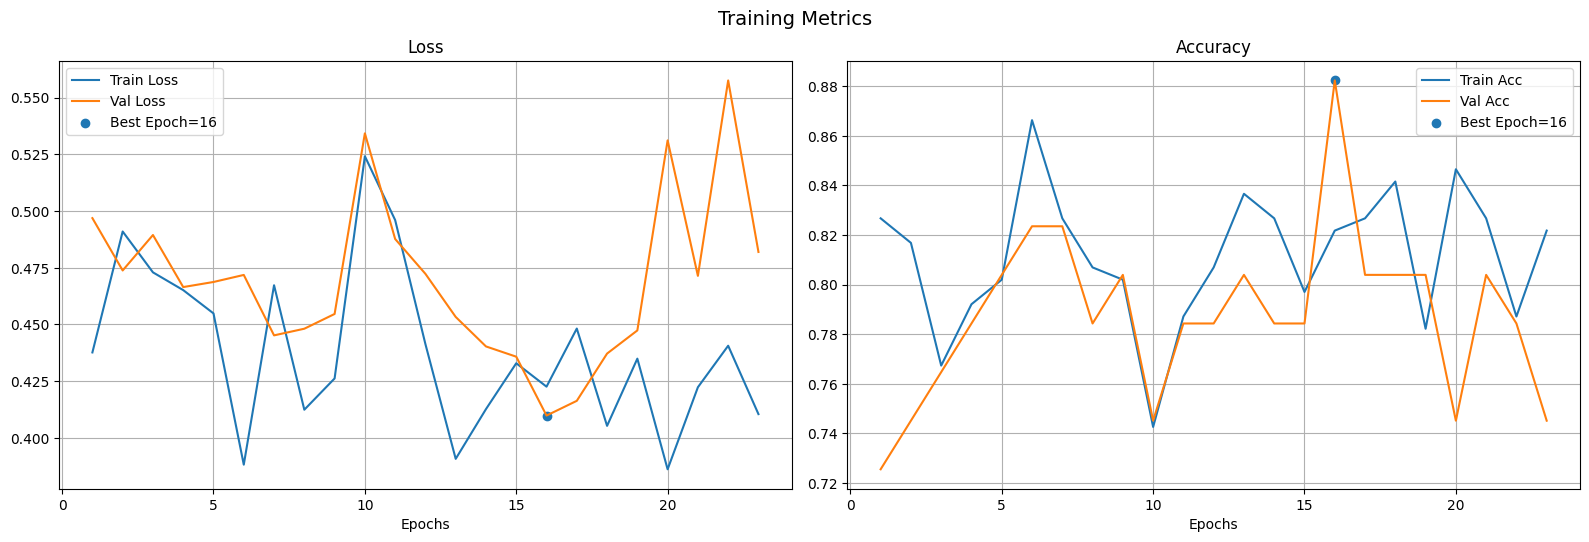

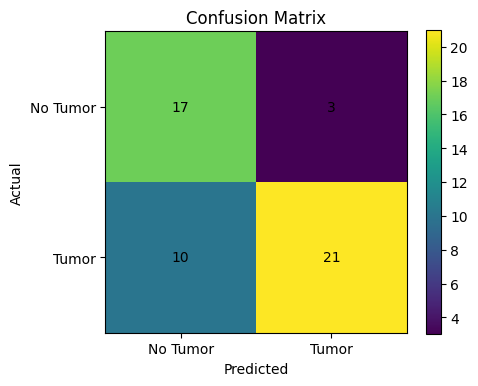

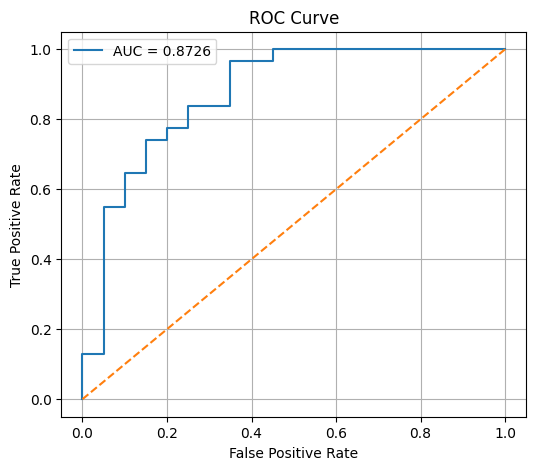

In [60]:
trained_model2, history2 = train_model_2(
    model=model2,
    train_loader=train_loader,
    val_loader=val_loader,
    device=device,
    epochs=epoch
)

plot_training_metrics(history2)

labels, probs = get_predictions(model2, val_loader, device)

metrics = compute_metrics(
    labels,
    probs,
    threshold=0.5,
    class_names=("No Tumor", "Tumor")
)

plot_roc_auc(model2, val_loader, device)

# CONCLUSION

This study developed and evaluated deep learning models for binary brain tumor classification using transfer learning. Three architectures were explored: a Simple CNN, ResNet-based model and an EfficientNet-based model, both initialized with pretrained ImageNet weights and fine-tuned on the target dataset.

The training pipeline incorporated best practices in deep learning, including selective layer freezing, differential learning rates for feature extraction and classification layers, and early stopping to prevent overfitting. Performance was evaluated using multiple metrics such as accuracy, precision, recall, F1-score, and confusion matrices, providing a comprehensive assessment beyond simple accuracy.

Among the models, the EfficientNet-based architecture demonstrated superior performance compared to the ResNet-based and Simple CNN model. This improvement can be attributed to EfficientNet’s compound scaling strategy, which enables more efficient feature extraction and better representation of subtle patterns in medical imaging data. The model showed stronger generalization on validation data, indicating its ability to capture relevant tumor features rather than memorizing training samples.

Overall, the results confirm that transfer learning with modern convolutional neural network architectures is effective for brain tumor classification tasks. The EfficientNet-based model, in particular, offers a strong balance of accuracy and efficiency, making it a suitable candidate for real-world deployment. Future work may include expanding the dataset, incorporating advanced evaluation metrics such as ROC-AUC, and exploring multi-class classification to distinguish between different tumor types.

Take note: Although SIMPLE CNN and ResNet models has higher accuracy, it seems that these models are failing to generalize (gap in training loss vs validation loss). Although EffiecientNet has lower accuracy and ROC Curve, EfficientNet has better generalization.